In [2]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries printed successfully!")

Libraries printed successfully!


In [5]:
#Load the Dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape of the dataset: ", df.shape)
df.head()

Shape of the dataset:  (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
#Looking at the data
df.info()
#The main problem here is the TotalCharges column. Its a money metric, so 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
#Checking for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
#Exposing the hidden problem
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
print("Nulls in TotalCharges now: ", df['TotalCharges'].isnull().sum())

Nulls in TotalCharges now:  11


In [12]:
#Drop the 11 rows: removing the 11 rows, b/c removing 11/7043 rows is 0.15%, so insignificant hence causing zero harm to the model and saving it from noise
df = df.dropna(subset=['TotalCharges'])
print("New shape of the dataset: ", df.shape)

New shape of the dataset:  (7032, 21)


In [16]:
#Fix the Target Column: Churn column
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Series([], Name: count, dtype: int64)


In [17]:
#Series([], Name: count, dtype: int64) this is the output of the above code 
#cell. This means that values in the Churn column are not exactly in the 
#"yes" or "no" form. So we debug. onto the next cell!

In [20]:
#Debugging the above cell
print(df['Churn'].unique())
print(df['Churn'].dtype)

[nan]
float64


In [22]:
#the above values mean that the map already ran but found nothing to match so 
#it converted everything to nan. the column is now float64 with all nulls. 
#The simple fix is to reload the data and redo all the steps in the right 
#order.

In [23]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

print(df['Churn'].unique())

['No' 'Yes']


In [24]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No': 0})
print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [31]:
churnrate = (1869/7032)*100
print(churnrate)
#26.578498293515356% = 25% is the churn rate of my dataset. Meaning roughly 
#1 of 4 customers left the company. In the above output the lesser number
# (1869) is the amount of customers churned(left) and 5163 stayed in the 
#company. 

26.578498293515356


In [30]:
#Now Dropping the CustomerID column as it has no value on dataset modeling
df = df.drop(columns=['customerID'])
print("Columns remaining:", df.shape[1])

Columns remaining: 20


In [35]:
#Till here what has been done: 
#loaded the dataset(all 7043x21 )
#Found and exposed 11 hidden missing values
#Dropped those 11 values
#Converted Churn to 0/1
#Dropped the useless CustomerID column
#DATA CLEANING IS DONE!!!!!!!!

#NOW STARTS EDA PART!!!!!!!!!

C:\Users\HP\AppData\Local\Temp\ipykernel_31224\3614833840.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Blues')


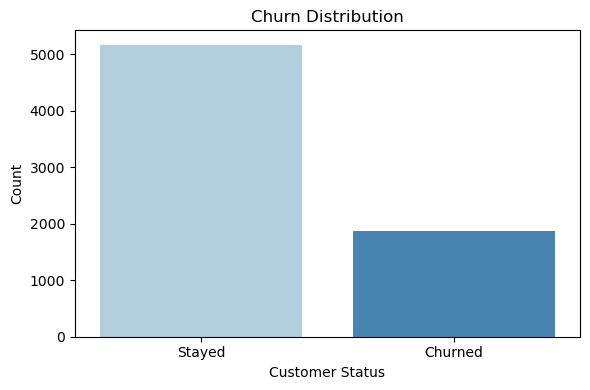

In [47]:
#Churn Distribution Chart
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Blues')
plt.title("Churn Distribution")
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.xlabel("Customer Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
#gives the visual representation of the customers who churned and who stayed

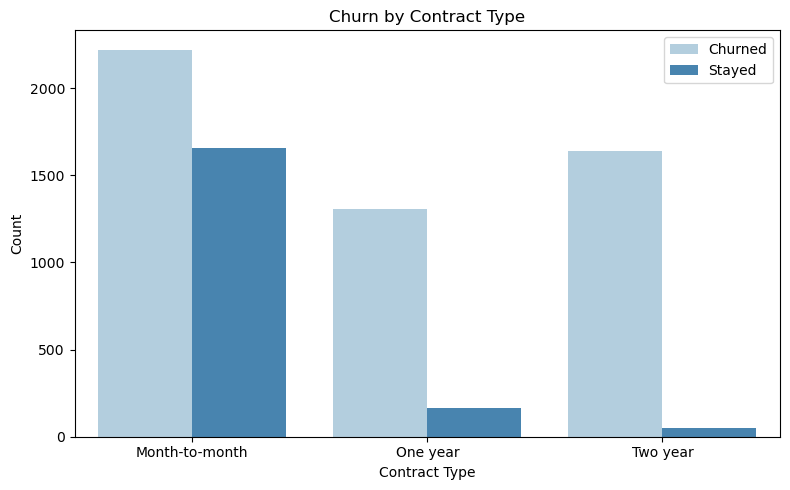

In [48]:
#Churn by Contract Type 
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Blues')
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.legend(labels=['Churned', "Stayed"])
plt.tight_layout()
plt.show()

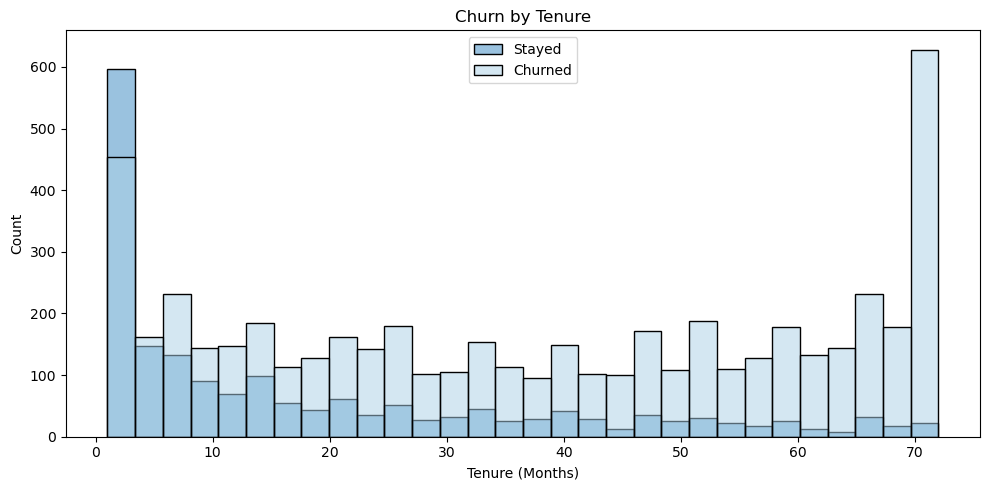

In [49]:
#Now we represent the customers who churned/stayed on the basis of tenure
#that is when do the people leave the company? which month do they leave the
#most or least
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Blues')
plt.title('Churn by Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_31224\891345916.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Blues')


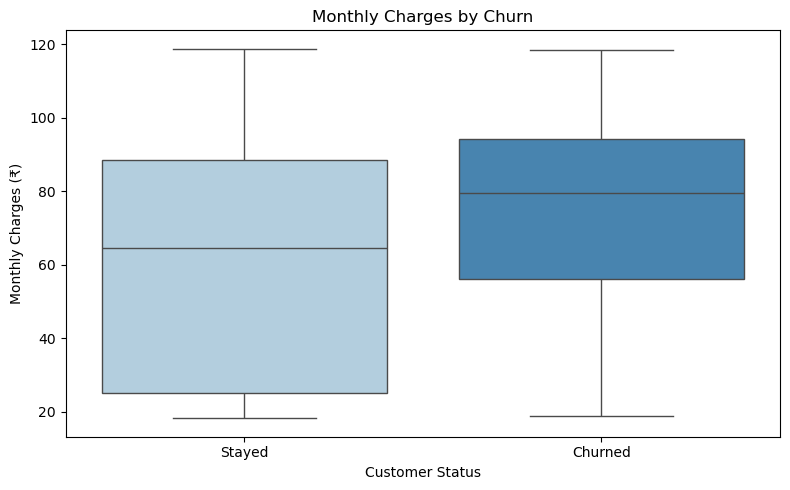

In [50]:
#Now we check churn due to MonthlyCharges. 
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Blues')
plt.title('Monthly Charges by Churn')
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.xlabel('Customer Status')
plt.ylabel('Monthly Charges (₹)')
plt.tight_layout()
plt.show()

In [52]:
"""
the above graphs tell us the story of the customers who left and who churned
wrt ContractType the most number of churned also the most difference
between the churned and stayed came from the customers with 
a 2 year contract. 

Now going towards more parameters in the data. we have the tenure
Tenure being the second parameter, we find that customers in the early months
churn the most, those who survive the first years become loyal and past month
70 hardly anyone churns, the most loyal customers are found in this timeline
"""


'\nthe above graphs tell us the story of the customers who left and who churned\nwrt ContractType the most number of churned also the most difference\nbetween the churned and stayed came from the customers with \na 2 year contract. \n\nNow going towards more parameters in the data. we have the tenure\nTenure being the second parameter, we find that customers in the early months\nchurn the most, those who survive the first years become loyal and past month\n70 hardly anyone churns, the most loyal customers are found in this timeline\n'

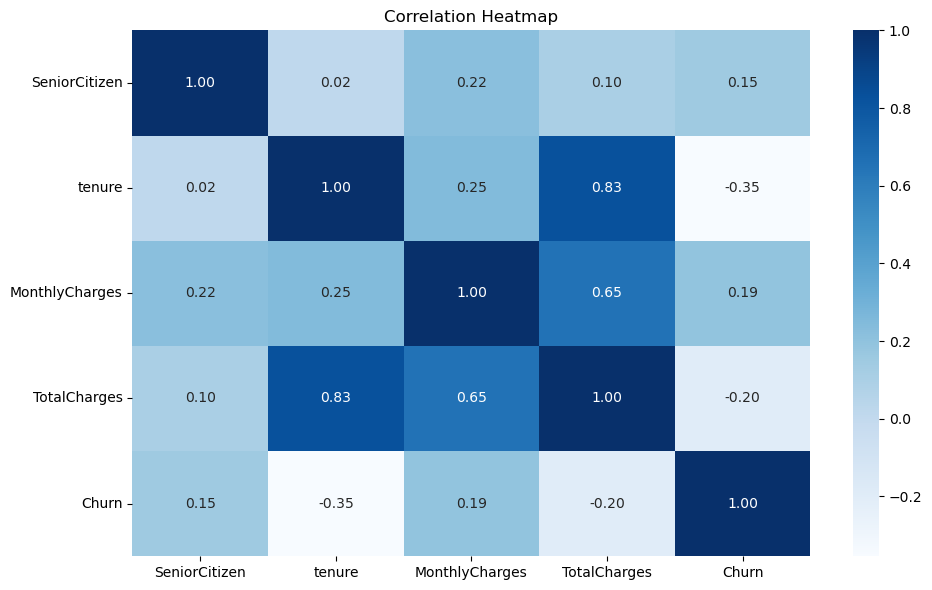

In [54]:
#Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()



In [55]:
"""converting all the remaining text columns into numbers as ML models only
understands numbers"""
print(df.dtypes)


gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [ ]:
"""
We have 15 columns that show object as their datatype. Convert them all to 
numbers before running the model.
Now, there are 2 types:
Binary Columns: with only 2 options: yes/no, male/female. 12 of these. 
we use Label Encoding: simply replace with 0 and 1.

Multi-category Columns(3+ options): there are three of these(InternetService,
Contract, PaymentMethod): use One-Hot Encoding: creating a seperate column
for each category
"""

In [56]:
#Encode Binary Columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV',
               'StreamingMovies', 'PaperlessBilling']

df[binary_cols] = df[binary_cols].apply(lambda x: x.map({'Yes': 1, 'No': 0,
                                                          'Male': 1, 'Female': 0,
                                                          'No internet service': 0,
                                                          'No phone service': 0}))
print("Done. Sample:")
print(df[binary_cols].head(3))

Done. Sample:
   gender  Partner  Dependents  PhoneService  MultipleLines  OnlineSecurity  \
0       0        1           0             0              0               0   
1       1        0           0             1              0               1   
2       1        0           0             1              0               1   

   OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  \
0             1                 0            0            0                0   
1             0                 1            0            0                0   
2             1                 0            0            0                0   

   PaperlessBilling  
0                 1  
1                 0  
2                 1  


In [58]:
#Encode the Multi-Category Columns
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)
print("New Shape: ", df.shape)
print(df.columns.tolist())

New Shape:  (7032, 24)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [59]:
#Split Features and Target

X = df.drop(columns=['Churn'])
#X is what the model will use to make predictions. Therefore the entire database sans Churn. 

y = df['Churn']
#Churn is what we're trying to predict. just the Churn column

print("X shape: ", X.shape)
print("y shape: ", y.shape)

X shape:  (7032, 23)
y shape:  (7032,)


In [62]:
#Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print("Training Size: ", X_train.shape)
print("Testing Size: ", X_test.shape)

Training Size:  (5625, 23)
Testing Size:  (1407, 23)


In [66]:
#Build the Baseline Model (Logistic Regression)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7874911158493249


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [69]:
"""
We use Logical Regression to make the baseline model. Its simple and fast. 
It basically draws a line between churners and non churners

max_iter = 1000 tells the model to try 1000 times to find the best line.
default is 100 but sometimes it is not enough

accuracy_score compares the predictions made by the model, think the 
database sans churn(X) with the real answers, think the actual churn 
column with the (y)

Since the Accuracy Socre for Logistic Regression gives misleading results 
on imbalanced data. so we note this number and move on. the REAL MODEL
we will use will be RANDOM FOREST
"""

'\nWe use Logical Regression to make the baseline model. Its simple and fast. \nIt basically draws a line between churners and non churners\n\nmax_iter = 1000 tells the model to try 1000 times to find the best line.\ndefault is 100 but sometimes it is not enough\n\naccuracy_score compares the predictions made by the model, think the \ndatabase sans churn(X) with the real answers, think the actual churn \ncolumn with the (y)\n\nSince the Accuracy Socre for Logistic Regression gives misleading results \non imbalanced data. so we note this number and move on. the REAL MODEL\nwe will use will be RANDOM FOREST\n'

In [70]:
#Build the Main Model (Random Forest)

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100,
                                  random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy: ", accuracy_score(y_test, rf_pred))


Random Forest Accuracy:  0.7782515991471215


In [72]:
"""
The Logistic Regression had a higher accuracy than the Random Forest, 
LR outperformed RF on raw accuracy. Serves as reminder that complex models 
do not always win.

Accuracy is misleading on imbalanced data. so we evaluate both models, LR 
and RF on ROC-AUC score and Recall before drawing conclusions
"""

'\nThe Logistic Regression had a higher accuracy than the Random Forest, \nLR outperformed RF on raw accuracy. Serves as reminder that complex models \ndo not always win.\n\nAccuracy is misleading on imbalanced data. so we evaluate both models, LR \nand RF on ROC-AUC score and Recall before drawing conclusions\n'

In [74]:
# ROC-AUC and Recall evaluation of LR and RF

from sklearn.metrics import classification_report, roc_auc_score

print("------Logistic Regression------")
print(classification_report(y_test, lr_pred))
print("ROC-AUC: ", roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]))

print("------Random Forest------")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))

------Logistic Regression------
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC:  0.832045182765529
------Random Forest------
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.61      0.45      0.52       374

    accuracy                           0.78      1407
   macro avg       0.72      0.67      0.69      1407
weighted avg       0.76      0.78      0.77      1407

ROC-AUC: 0.8146253837273709


In [81]:
"""
After evaluating LR and RF on both ROC-AUC and Recall - the metrics that 
actually matter for imbalanced churn data. 

LR outperformed RF with an AUC of 0.83 versus 0.81

This is surprising as RF is canonically a better and more accurate model 
than LR. But wrt to the result, I'm going forward with LR as my main model 
as it is more accurate and more interpretable, which will matter in a context
of explaination. 
"""

"\nAfter evaluating LR and RF on both ROC-AUC and Recall - the metrics that \nactually matter for imbalanced churn data. \n\nLR outperformed RF with an AUC of 0.83 versus 0.81\n\nThis is surprising as RF is canonically a better and more accurate model \nthan LR. But wrt to the result, I'm going forward with LR as my main model \nas it is more accurate and more interpretable, which will matter in a context\nof explaination. \n"

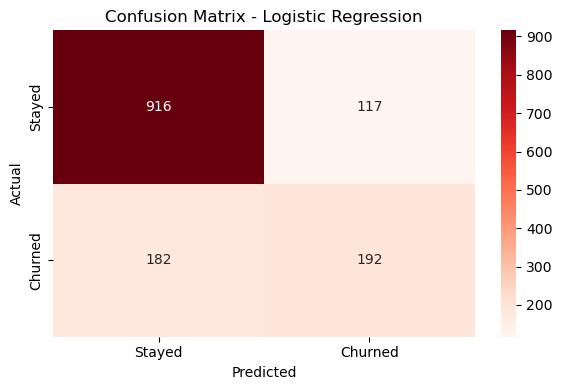

In [82]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [84]:
"""
The reading of the above mentioned Confusion Matrix

Top Left - 916: Predicted: Stayed. Actual: Stayed. CORRECT. These are the 
customers that the model identified as safe. No action needed. True Positive

Top Right - 117: Predicted: Churned. Actual: Stayed. INCORRECT. These are 
false alarms, customers who were never going to leave but the model flagged
them. This becomes a point of possible wastage of retention budget. False Negative

Bottom Left - 182: Predicted: Stayed. Actual: Churned. INCORRECT. This is a 
dangerous mistake. Real churners, at the risk of leaving that the model missed. 
These customers walked out and nobody payed any attention. This is revenue lost
forever. False Positive

Bottom Right - 192: Predicted: Churned. Actual: Churned. CORRECT. These are actual
churners that were accurately predicted by the model. True Negative.
"""

'\nThe reading of the above mentioned Confusion Matrix\n\nTop Left - 916: Predicted: Stayed. Actual: Stayed. CORRECT. These are the \ncustomers that the model identified as safe. No action needed. True Positive\n\nTop Right - 117: Predicted: Churned. Actual: Stayed. INCORRECT. These are \nfalse alarms, customers who were never going to leave but the model flagged\nthem. This becomes a point of possible wastage of retention budget. False Negative\n\nBottom Left - 182: Predicted: Stayed. Actual: Churned. INCORRECT. This is a \ndangerous mistake. Real churners, at the risk of leaving that the model missed. \nThese customers walked out and nobody payed any attention. This is revenue lost\nforever. False Positive\n\nBottom Right - 192: Predicted: Churned. Actual: Churned. CORRECT. These are actual\nchurners that were accurately predicted by the model. True Negative.\n'

C:\Users\HP\AppData\Local\Temp\ipykernel_31224\2312336327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="Reds_r")


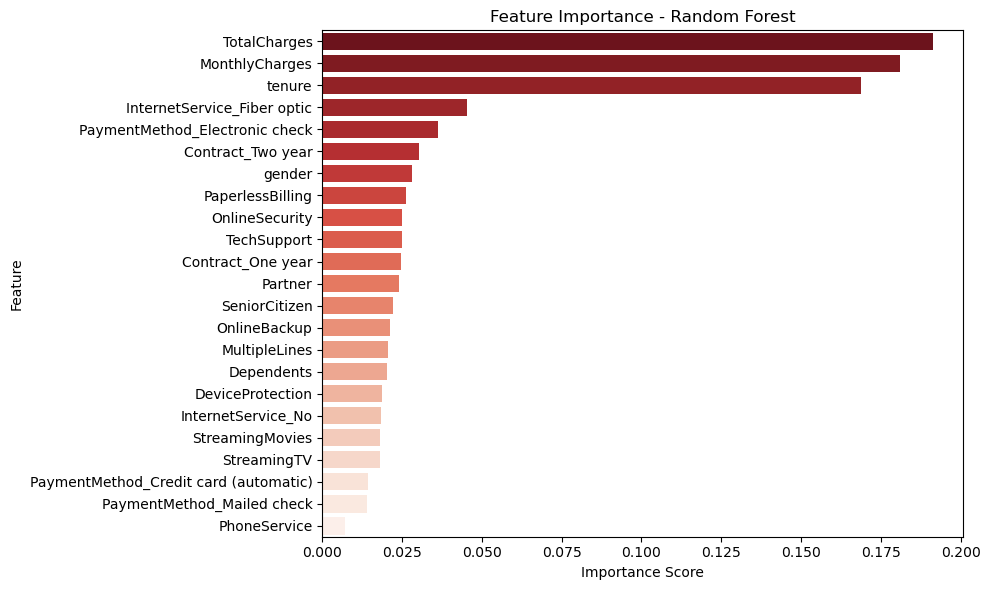

In [97]:
#Feature Importance Graph

feature_importance = pd.Series(rf_model.feature_importances_, index = X.columns)
feature_importance = feature_importance.sort_values(ascending = False)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="Reds_r")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [99]:
"""
Despite Logical Regression being the more accurate model versus Random Forest 
Classifier, we will go with the latter because it has a built in "features_importances_" 
attribute that gives clean scores per feature. LR does not give this as cleanly 
or intuitively. 

As shown in the graph above, the big 3 features in the entire dataset are: 
TotalCharges, Monthly Charges and the Tenure

So in reality, the top three are essentially Money and Time. How much one 
pays and how long they stick around :|
"""

'\nDespite Logical Regression being the more accurate model versus Random Forest \nClassifier, we will go with the latter because it has a built in "features_importances_" \nattribute that gives clean scores per feature. LR does not give this as cleanly \nor intuitively. \n\nAs shown in the graph above, the big 3 features in the entire dataset are: \nTotalCharges, Monthly Charges and the Tenure\n\nSo in reality, the top three are essentially Money and Time. How much one \npays and how long they stick around :|\n'

In [101]:
#CORE MODEL DONEEEEE!!!!!!
"""
Here is what was done till this point:

Data loading and cleaning
Hidden missing value detection
EDA with 4 charts and business insights 
Encoding all columns 
Train test split 
Logistic Regression baseline 
Random Forest challenger 
Proper evaluation — accuracy, ROC-AUC, recall 
Confusion matrix 
Feature importance 

"""

'\nHere is what was done till this point:\nData loading and cleaning\nHidden missing value detection\nEDA with 4 charts and business insights \nEncoding all columns \nTrain test split \nLogistic Regression baseline \nRandom Forest challenger \nProper evaluation — accuracy, ROC-AUC, recall \nConfusion matrix \nFeature importance \n\n'

In [103]:
"""
All of this goes into Streamlit Dashboard - a proper interactive web app
But before Streamlit, the trained model needs to be saved so Streamlit can 
load and use it
"""

SyntaxError: invalid syntax (1084031152.py, line 1)

In [104]:
#Saving the model

import pickle 

with open('customer_churn_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(),f)

print("Model saved successfully")

Model saved successfully
